In [1]:
import os
import pickle
import mne
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from mne.stats import f_mway_rm
from mne.stats import f_threshold_mway_rm
from util_regions import *

# GLOBAL VARS
ROOT = r"C:\Users\hz3752\Box\MEG\Data\kidslang_data"
os.chdir(ROOT)

mri_dir = os.path.join(ROOT, 'mri')
#stc_dir = os.path.join(ROOT, 'stc')
#stats_dir = os.path.join(ROOT, 'stats')

# Configure experiment variables

In [2]:
exp_dirs = ['structure_signed', 'transposed_signed']
exp_dirs = ['structure_signed', 'transpose_signed']

experiments = ['exp1', 'exp2', 'both']
comparisons = ['sentences', 'anova', 'nouns', 'quantifiers']

exp_dir_dict = {
    experiments[0]: exp_dirs[0],
    experiments[1]: exp_dirs[1]
}

In [3]:
experiment = experiments[1]
comparison = comparisons[0]

# Specify Subject List

## Experiment 1

["R1260","R1421","R1600","R1718","R1840",
            "R1891","R1898","R1905","R1907","R1908",
            "R1914","R1917","R1921","R1928","R1934",
            "R1942","R1988","R2076","R2077","R2079",
            "R2089"]
## Experiment 2
["R1260","R1421","R1600","R1718","R1840",
            "R1890","R1891","R1897","R1898","R1904",
            "R1905","R1907","R1908","R1914","R1917",
            "R1921","R1928","R1934","R1942","R1988",
            "R2076","R2077","R2079","R2089"]

In [4]:
kidslang_subjects = ['Y0312', 'Y0366', 'Y0367', 'Y0371', 'Y0372', 'Y0373', 
                     'Y0374', 'Y0375', 'Y0376', 'Y0377', 'Y0378', 'Y0380', 
                     'Y0381', 'Y0382', 'Y0383', 'Y0384', 'Y0387', 'Y0388',
                     'Y0390', 'Y0392', 'Y0393']


exp1_subjects = ["R1260","R1421","R1600","R1718","R1840",
                 "R1891","R1898","R1905","R1907","R1908",
                 "R1914","R1917","R1921","R1928","R1934",
                 "R1942","R1988","R2076","R2077","R2079",
                 "R2089"]

exp2_subjects = ["R1260","R1421","R1600","R1718","R1840",
                 "R1890","R1891","R1897","R1898","R1904",
                 "R1905","R1907","R1908","R1914","R1917",
                 "R1921","R1928","R1934","R1942","R1988",
                 "R2076","R2077","R2079","R2089"]

combined_subjects = sorted(list(set(exp1_subjects) & set(exp2_subjects)))

kidslang_conditions = ['interactive', 'non-interactive'] # Word 2 counts only
cond_list = ['listening_phrase',  'listening_object', 'dialogue_phrase', 'dialogue_object'] #From Slides

subjects = kidslang_subjects
conditions = kidslang_conditions



In [5]:
# exp1_conditions = ['all_bare',  'all_noun',  'all_sent', 
#                    'some_bare', 'some_noun', 'some_sent',
#                    'no_bare',   'no_noun',   'no_sent',
#                    'the_bare',  'the_noun',  'the_sent',
#                    'one_noun',  'two_noun',  'three_noun']

# exp2_conditions = ['all_sent',  'all_trans1',  'all_trans2', 
#                    'some_sent', 'some_trans1', 'some_trans2',
#                    'no_sent',   'no_trans1',   'no_trans2',
#                    'the_sent',  'the_trans1',  'the_trans2']

# noun_conditions = ['all_noun', 'some_noun', 'no_noun', 'the_noun']

# sentence_conditions = ['all_sent', 'some_sent', 'no_sent', 'the_sent']

# sentence_conditions_comb = ['all_sent_exp1', 'some_sent_exp1', 'no_sent_exp1', 'the_sent_exp1',
#                             'all_sent_exp2', 'some_sent_exp2', 'no_sent_exp2', 'the_sent_exp2']

# quant_sent_comb = ['all_sent_exp1', 'some_sent_exp1', 'no_sent_exp1',
#                    'all_sent_exp2', 'some_sent_exp2', 'no_sent_exp2']

In [6]:
# subjects = []
# conditions = []

# if experiment == 'exp1' and comparison == 'anova':    
#     subjects = exp1_subjects
#     conditions = exp1_conditions
# elif experiment == 'exp1' and comparison == 'sentences':
#     subjects = exp1_subjects
#     conditions = sentence_conditions
# elif experiment == 'exp1' and comparison == 'nouns':
#     subjects = exp1_subjects
#     conditions = noun_conditions
# elif experiment == 'exp2' and comparison == 'anova':
#     subjects = exp2_subjects
#     conditions = exp2_conditions
# elif experiment == 'exp2' and comparison == 'sentences':
#     subjects = exp2_subjects
#     conditions = sentence_conditions
# elif experiment == 'both' and comparison == 'sentences':
#     subjects = combined_subjects
#     conditions = sentence_conditions_comb
# elif experiment == 'both' and comparison == 'quantifiers':
#     subjects = combined_subjects
#     conditions = quant_sent_comb
# else:
#     pass

# Read in the STCs

In [7]:
# data structure
epoch_tmin = -0.1
epoch_tmax = 0.8
times = np.arange(int(epoch_tmin*1000), int(epoch_tmax*1000+1), 1)
n_times = len(times)        # number of time points
n_cond = len(conditions)    # number of conditions
n_subj = len(subjects)      # number of subjects
stcs = []                   # empty list for appending stc files

def get_STC(exp_dir, subj, exp, cond):
    
    stc_fname = os.path.join(stc_dir, exp_dir, 
                                 '%s','%s_%s_%s_dSPM') % (cond, subj, exp, cond)
    
    stc = mne.read_source_estimate(stc_fname, subject='fsaverage')
    
    return stc

for c, cond in enumerate(conditions):
    print('Reading in STCs for condition %s' % cond) 
    
    for s, subj in enumerate(subjects):
        
        exp_dir = None
        subj_exp = subj + '_' + experiment
        stc = None
        
        if experiment == 'both':
            curr_exp = cond.split('_')[-1]
            exp_dir = exp_dir_dict[curr_exp]
            cond_name = '_'.join(cond.split('_')[:-1])
            stc = get_STC(exp_dir, subj, curr_exp, cond_name)
            
        else:
            exp_dir = exp_dir_dict[experiment]
            stc = get_STC(exp_dir, subj, experiment, cond)
        
        stcs.append(stc)

Reading in STCs for condition interactive


NameError: name 'stc_dir' is not defined

# Define ROI Labels

## Aparc Parcellation

In the following cells, I am using brain regions using the Aparc parcellation, and I am mostly using the ROIs defined in Tulling et al. (2021), since Maxime's study involves the comprehension of modal verbs, which in some sense are involved in quantification (over possible worlds). 

In [8]:
mne.datasets.fetch_aparc_sub_parcellation(subjects_dir=mri_dir,verbose=True)

annot_name = 'aparc'
left_labels = mne.read_labels_from_annot('fsaverage', annot_name, subjects_dir = mri_dir, hemi = 'lh')
right_labels = mne.read_labels_from_annot('fsaverage', annot_name, subjects_dir = mri_dir, hemi = 'rh')

TP = 'temporalpole'
IPS = 'superiorparietal'
supramarginal = 'supramarginal'
inferior_parietal = 'inferiorparietal'
PCC = 'posteriorcingulate'
precuneus = 'precuneus'
rrACC = 'rostralanteriorcingulate'
vmPFC = 'medialorbitofrontal'
fusiform = 'fusiform'

Reading labels from parcellation...
   read 35 labels from C:\Users\hz3752\Box\MEG\Data\kidslang_data\mri\fsaverage\label\lh.aparc.annot
Reading labels from parcellation...
   read 34 labels from C:\Users\hz3752\Box\MEG\Data\kidslang_data\mri\fsaverage\label\rh.aparc.annot


In [9]:
hemi = 'lh'

left_TP        = [label for label in left_labels if label.name == '%s-%s' % (TP, hemi)][0]
left_IPS       = [label for label in left_labels if label.name == '%s-%s' % (IPS, hemi)][0]
left_TPJ       = [label for label in left_labels if label.name == '%s-%s' % (supramarginal, hemi)][0] + \
                 [label for label in left_labels if label.name == '%s-%s' % (inferior_parietal, hemi)][0]
left_PCC       = [label for label in left_labels if label.name == '%s-%s' % (PCC, hemi)][0]
left_Precuneus = [label for label in left_labels if label.name == '%s-%s' % (precuneus, hemi)][0]
left_rrACC     = [label for label in left_labels if label.name == '%s-%s' % (rrACC, hemi)][0]
left_vmPFC     = [label for label in left_labels if label.name == '%s-%s' % (vmPFC, hemi)][0]
left_fusiform  = [label for label in left_labels if label.name == '%s-%s' % (fusiform, hemi)][0]

In [10]:
hemi = 'rh'

right_TP        = [label for label in right_labels if label.name == '%s-%s' % (TP, hemi)][0]
right_IPS       = [label for label in right_labels if label.name == '%s-%s' % (IPS, hemi)][0]
right_TPJ       = [label for label in right_labels if label.name == '%s-%s' % (supramarginal, hemi)][0] + \
                  [label for label in right_labels if label.name == '%s-%s' % (inferior_parietal, hemi)][0]
right_PCC       = [label for label in right_labels if label.name == '%s-%s' % (PCC, hemi)][0]
right_Precuneus = [label for label in right_labels if label.name == '%s-%s' % (precuneus, hemi)][0]
right_rrACC     = [label for label in right_labels if label.name == '%s-%s' % (rrACC, hemi)][0]
right_vmPFC     = [label for label in right_labels if label.name == '%s-%s' % (vmPFC, hemi)][0]

## Pallier Labels

These labels come from the Pallier et al. 2010 study. They include the LATL, the pSTS, the TPJ, and the LIFG.

In [11]:
annot_name = 'Pallier_2011_30_final_roi'
pallier_labels = mne.read_labels_from_annot('fsaverage', annot_name, subjects_dir = mri_dir, hemi = 'lh')
pallier_label_name = 'LATL-lh'
pallier_label = [label for label in pallier_labels if label.name == pallier_label_name][0]

Reading labels from parcellation...


OSError: No such file C:\Users\hz3752\Box\MEG\Data\kidslang_data\mri\fsaverage\label\lh.Pallier_2011_30_final_roi.annot, candidate parcellations in that directory:
aparc
aparc.a2005s
aparc.a2009s
aparc_sub
oasis.chubs
PALS_B12_Brodmann
PALS_B12_Lobes
PALS_B12_OrbitoFrontal
PALS_B12_Visuotopic
Yeo2011_17Networks_N1000
Yeo2011_7Networks_N1000

## Brodmann Area Parcellation

In this cell, you can retrieve whichever ROI corresponding to a Brodmann Area.

In [12]:
# read label annotation
labels = mne.read_labels_from_annot(subject='fsaverage', parc='PALS_B12_Brodmann', subjects_dir = mri_dir)

ba = 7
hemi = 'lh'

ba_roi = [label for label in labels if label.name == 'Brodmann.%d-%s' % (ba, hemi)][0]

Reading labels from parcellation...
   read 82 labels from C:\Users\hz3752\Box\MEG\Data\kidslang_data\mri\fsaverage\label\lh.PALS_B12_Brodmann.annot
   read 46 labels from C:\Users\hz3752\Box\MEG\Data\kidslang_data\mri\fsaverage\label\rh.PALS_B12_Brodmann.annot


## Select ROI

In [13]:
roi = get_LATL()
#roi = left_TP
#roi = pallier_label
#roi = ba_roi

#roi_hemi = roi.name.split('-')[1]
#hemisphere = 'Left' if roi_hemi == 'lh' else 'Right'
hemisphere = 'Left'

Reading labels from parcellation...
   read 226 labels from C:\Users\hz3752\Box\MEG\Data\kidslang_data\mri\fsaverage\label\lh.aparc_sub.annot


# ROI Analysis: ANOVA

## Look at the effect of quantifier across sentences or phrases

In [136]:
# The variable storing all of the data will be in data
data = []

for c, cond in enumerate(conditions):

    data_tmp = np.empty((n_subj, n_times))

    for s, subj in enumerate(subjects):
        
        # get the STC data from Subject s for Condition c
        idx = s+c*n_subj
        subj_stc = stcs[idx]
        data_tmp[s,:] = np.mean(subj_stc.in_label(roi).data, axis=0)
        
    data.append(data_tmp)

# Select Time Region for Analysis

In [137]:
toi_min = 0
toi_max = 800
toi_min_idx = np.squeeze(np.where(times==toi_min))
toi_max_idx = np.squeeze(np.where(times==toi_max))
toi = np.arange(toi_min, toi_max+1, 1)
toi_idx = np.arange(toi_min_idx, toi_max_idx+1, 1)

data_time = []
    
for i, condition in enumerate(conditions):
    data_time.append(data[i][:,toi_idx])

## rmANOVA function


In [138]:
# For clustering, we don't need the p-values
return_pvals = False

def stat_fun(*args):
    # Return only the F-values
    return f_mway_rm(np.swapaxes(args, 1, 0), factor_levels=factor_levels,
                     effects=effects, return_pvals=False)[0]

## Stats Parameters

In [139]:
X = data_time
tail = 1
p_thresh = 0.05
n_permutations = 10000

# Estimating F-test threshold
factor_levels = [4, 1]
effects = 'A' # A - main effect of A, B - main effect of B, A:B - interaction effect
f_thresh = f_threshold_mway_rm(n_subj, factor_levels, effects, p_thresh)

# rmANOVA over the ROI

In [140]:
print("Launching clustering test.")
print("Threshold: %s" % f_thresh)

F_obs, clusters, clusters_pvals, h0 = clu = \
    mne.stats.permutation_cluster_test(X, 
                                       tail = tail,
                                       threshold = f_thresh,
                                       stat_fun = stat_fun,
                                       n_permutations = n_permutations,
                                       buffer_size=None,
                                       out_type='indices',
                                       n_jobs=1)

Launching clustering test.
Threshold: 2.737492307751068
stat_fun(H1): min=0.023020 max=3.081432
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

## Print out clustering results

In [141]:
np.set_printoptions(suppress=True)

p_thresh = 0.05
print(clusters_pvals)

good_cluster_inds = np.where(clusters_pvals < p_thresh)[0]
np.set_printoptions(suppress=True)
print(good_cluster_inds)

[0.7372 0.8101 0.7997]
[]


## Print out the time window of a good cluster

In [142]:
for good_cluster_idx in good_cluster_inds:
    
    cluster = clusters[good_cluster_idx][0]
    p_value = clusters_pvals[good_cluster_idx]
    
    cluster_start = cluster[0]
    cluster_end = cluster[-1]

    print("Cluster %s: %s - %s ms, p-value: %s" % (good_cluster_idx, cluster_start, cluster_end, p_value))

# Plot the Main Effect of A (Quantifier)

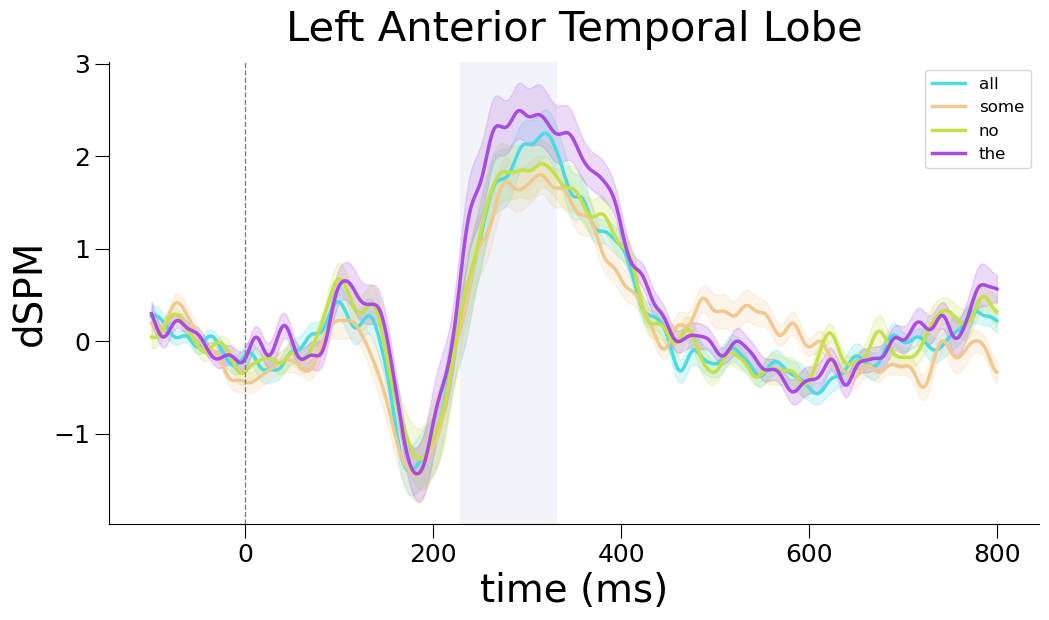

In [130]:
color_list = ['#4BDBE1', '#F0C890', '#C5E04A', '#A94AE0'] 
#color_list = ['#30E5E1', '#E6CF5E', '#E653C3']

determiner_list = ['all', 'some', 'no', 'the']
experiment_list = ['exp1']
title = '%s Anterior Temporal Lobe' % hemisphere

n_det = len(determiner_list)
n_exp = len(experiment_list)

plt.figure(figsize=(12,6))

# n_det x n_times
data_avg = np.empty((n_det, np.shape(data)[2]))
data_sem = np.empty((n_det, np.shape(data)[2]))

for det_count, det_name in enumerate(determiner_list):
    
    # n_exp x n_subj x n_times
    data_sel = np.empty((n_exp, np.shape(data)[1], np.shape(data)[2]))
        
    for exp_count, exp_name in enumerate(experiment_list):

        i = det_count + exp_count * n_det
        data_sel[exp_count] = data[i]
            
    data_avg[det_count] = data_sel.mean(axis=(0, 1))
    data_sem[det_count] = data_sel.std(axis=(0, 1)) / np.sqrt(n_subj*2)

    plt.plot(times, data_avg[det_count], lw=2.5, color=color_list[det_count], label=det_name)
    plt.fill_between(times, data_avg[det_count]+data_sem[det_count], 
                            data_avg[det_count]-data_sem[det_count], 
                            alpha=0.2, color=color_list[det_count])

for good_cluster_idx in good_cluster_inds:
    
    cluster = clusters[good_cluster_idx][0]
    cluster_start = cluster[0]
    cluster_end = cluster[-1]
    
    plt.axvspan(cluster_start, cluster_end, facecolor='#AFB3E0', alpha=0.15)   

plt.axvline(x=0, lw=1, ls='--', color='gray')

plt.xlabel('time (ms)', fontsize=28)
plt.ylabel('dSPM', fontsize=28)
plt.title(title, fontsize=30, pad=15)
plt.tick_params(labelsize=18, length=10)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.locator_params(axis='y', nbins=6) 
plt.legend(ncol=1, fontsize=12, loc='upper right')

# Plot Main Effect B

all Structure Experiment : 0
some Structure Experiment : 1
no Structure Experiment : 2
all Transpose Experiment : 3
some Transpose Experiment : 4
no Transpose Experiment : 5


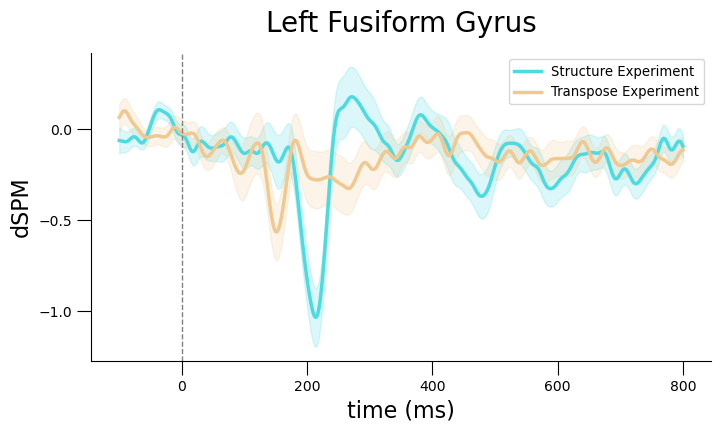

In [238]:
color_list = ['#4BDBE1', '#F0C890', '#C5E04A', '#A94AE0'] 

determiner_list = ['all', 'some', 'no']
experiment_list = ['Structure Experiment', 'Transpose Experiment']
title = '%s Fusiform Gyrus' % hemisphere

n_det = len(determiner_list)
n_exp = len(experiment_list)

plt.figure(figsize=(8,4))

data_avg = np.empty((n_exp, np.shape(data)[2]))
data_sem = np.empty((n_exp, np.shape(data)[2]))

for exp_count, exp_name in enumerate(experiment_list):
    
    # n_det x n_subj x n_times
    data_sel = np.empty((n_det, np.shape(data)[1], np.shape(data)[2]))
        
    for det_count, det_name in enumerate(determiner_list):

        i = det_count + exp_count * n_det
        print("%s %s : %s" % (det_name, exp_name, i))
        data_sel[det_count] = data[i]
            
    data_avg[exp_count] = data_sel.mean(axis=(0, 1))
    data_sem[exp_count] = data_sel.std(axis=(0, 1)) / np.sqrt(n_subj*2)

    plt.plot(times, data_avg[exp_count], lw=2.5, color=color_list[exp_count], label=exp_name)
    plt.fill_between(times, data_avg[exp_count]+data_sem[exp_count], 
                            data_avg[exp_count]-data_sem[exp_count], 
                            alpha=0.2, color=color_list[exp_count])

for good_cluster_idx in good_cluster_inds:
    
    cluster = clusters[good_cluster_idx][0]
    cluster_start = cluster[0]
    cluster_end = cluster[-1]
    
    plt.axvspan(cluster_start, cluster_end, facecolor='#AFB3E0', alpha=0.15)   

plt.axvline(x=0, lw=1, ls='--', color='gray')

plt.xlabel('time (ms)', fontsize=16)
plt.ylabel('dSPM', fontsize=16)
plt.title(title, fontsize=20, pad=15)
plt.tick_params(labelsize=10, length=10)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.locator_params(axis='y', nbins=6) 
plt.legend(ncol=1, fontsize=9.5, loc='upper right')

# Plot the averages of each condition within the cluster

In [131]:
cluster_idx = 0
cluster = clusters[good_cluster_inds[cluster_idx]][0]
cluster_start = cluster[0]
cluster_end = cluster[-1]

cluster_avgs = [data_avg[i, cluster_start+100:cluster_end+100].mean() 
                      for i in range(len(determiner_list))]

cluster_sems = [data_sem[i, cluster_start+100:cluster_end+100].std()
                      for i in range(len(determiner_list))]

print("Cluster Averages: ", cluster_avgs)
print("Cluster Errors: ", cluster_sems)

Cluster Averages:  [1.6315465851228697, 1.3783448360984436, 1.5404410850642543, 2.096425886659728]
Cluster Errors:  [0.050663179849302575, 0.0564063205146666, 0.04322734266804724, 0.03845195125459452]


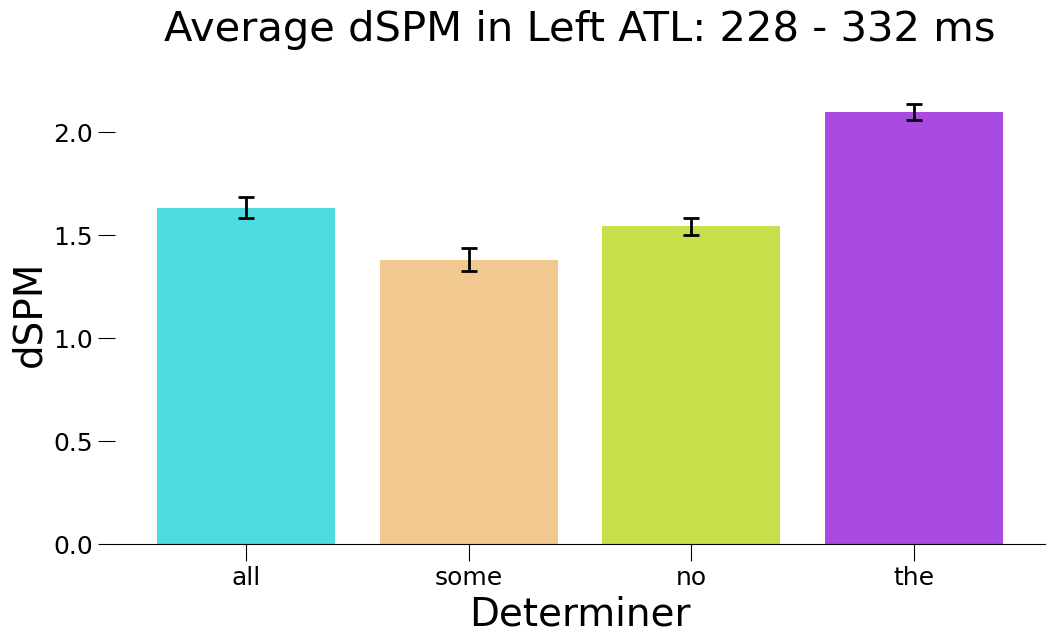

In [132]:
title = 'Average dSPM in %s ATL: %s - %s ms' % (hemisphere, cluster_start, cluster_end)

plt.figure(figsize=(12,6))

plt.bar(determiner_list, cluster_avgs, yerr=cluster_sems, 
        color=color_list, error_kw=dict(ecolor='black', lw=2, capsize=6, capthick=2))

plt.xlabel("Determiner", fontsize=28)
plt.ylabel("dSPM", fontsize=28)
plt.title(title, fontsize=30, pad=30)
plt.tick_params(labelsize=18, length=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.locator_params(axis='y', nbins=6)


# Perform pairwise comparisons between the conditions

## For each subject, calculate the average value for the conditions in the significant region

The result should be a $\text{n_subj} \times \text{n_cond}$ matrix. The rows are the subjects, and the columns are the conditions.

In [133]:
subj_avg = np.empty((n_cond, n_subj))

for cond_i, cond_name in enumerate(conditions):
    subj_avg[cond_i] = data[cond_i][:, cluster_start+100:cluster_end+100].mean(axis=1)
    
all_idx  = 0
some_idx = 1
no_idx   = 2
the_idx  = 3

# Only One Experiment
all_sent  = subj_avg[all_idx]
some_sent = subj_avg[some_idx]
no_sent   = subj_avg[no_idx]
the_sent  = subj_avg[the_idx]

# Both Experiments Combined
# all_sent  = np.concatenate((subj_avg[all_idx], subj_avg[all_idx + n_det]))
# some_sent = np.concatenate((subj_avg[some_idx], subj_avg[some_idx + n_det]))
# no_sent   = np.concatenate((subj_avg[no_idx], subj_avg[no_idx + n_det]))
# the_sent  = np.concatenate((subj_avg[the_idx], subj_avg[the_idx + n_det]))

# all_sent  = np.mean((subj_avg[all_idx], subj_avg[all_idx + n_det]), axis=0)
# some_sent = np.mean((subj_avg[some_idx], subj_avg[some_idx + n_det]), axis=0)
# no_sent   = np.mean((subj_avg[no_idx], subj_avg[no_idx + n_det]), axis=0)

# Compare STCs from Experiment 1 in this ROI and time window
# all_sent  = subj_avg[all_idx]
# some_sent = subj_avg[some_idx]
# no_sent   = subj_avg[no_idx]

# Compare STCs from Experiment 2 in this ROI and time window
# all_sent  = subj_avg[all_idx + n_det]
# some_sent = subj_avg[some_idx + n_det]
# no_sent   = subj_avg[no_idx + n_det]

In [134]:
print("Executing t-tests within cluster %s, %s - %s ms" % (cluster_idx, cluster_start, cluster_end))

print("Testing 'All' versus 'Some' ")
print("p = %s\n" % ttest_rel(all_sent, some_sent)[1])

print("Testing 'All' versus 'No' ")
print("p = %s\n" % ttest_rel(all_sent, no_sent)[1])

print("Testing 'All' versus 'The' ")
print("p = %s\n" % ttest_rel(all_sent, the_sent)[1])

print("Testing 'Some' versus 'No' ")
print("p = %s\n" % ttest_rel(some_sent, no_sent)[1])

print("Testing 'Some' versus 'The' ")
print("p = %s\n" % ttest_rel(some_sent, the_sent)[1])

print("Testing 'No' versus 'The' ")
print("p = %s\n" % ttest_rel(no_sent, the_sent)[1])

Executing t-tests within cluster 0, 228 - 332 ms
Testing 'All' versus 'Some' 
p = 0.07628627165692778

Testing 'All' versus 'No' 
p = 0.6238351274268361

Testing 'All' versus 'The' 
p = 0.004235681091415788

Testing 'Some' versus 'No' 
p = 0.4443465952366321

Testing 'Some' versus 'The' 
p = 0.0015690814755045226

Testing 'No' versus 'The' 
p = 0.011718029509007294



# Plot the Interaction Effect

## Plot the "all" sentences across both experiments

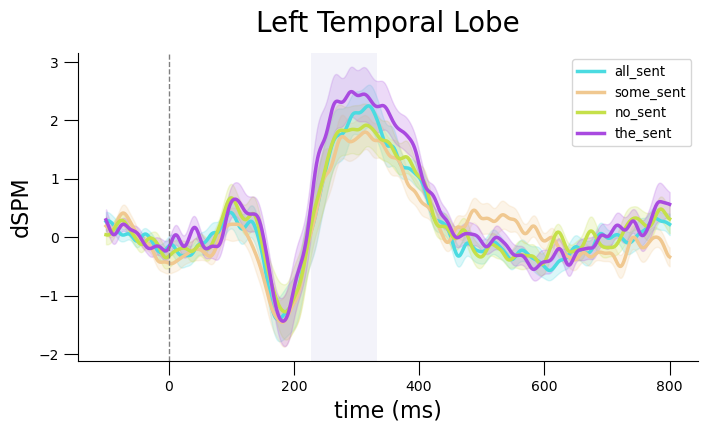

In [128]:
#color_list = ['#C3F52C', '#F5D32C', '#C5E04A', '#742CF5', '#594975', '#717959', '#756F50', '#A94AE0'] 
color_list = ['#4BDBE1', '#F0C890', '#C5E04A', '#A94AE0'] 

determiner_list = ['all', 'some', 'no']
title = 'Left Temporal Lobe'

plt.figure(figsize=(8,4))

data_avg = np.empty((n_cond, np.shape(data)[2]))
data_sem = np.empty((n_cond, np.shape(data)[2]))

# epoch period
for i, condition in enumerate(conditions):
    data_avg[i] = data[i].mean(axis=0)
    data_sem[i] = data[i].std(axis=0) / np.sqrt(n_subj)
    
    plt.plot(times, data_avg[i], lw=2.5, color=color_list[i], label=conditions[i])
    plt.fill_between(times, data_avg[i]+data_sem[i], data_avg[i]-data_sem[i], alpha=0.2, color=color_list[i])

for good_cluster_idx in good_cluster_inds:
    
    cluster = clusters[good_cluster_idx][0]
    cluster_start = cluster[0]
    cluster_end = cluster[-1]
    
    plt.axvspan(cluster_start, cluster_end, facecolor='#AFB3E0', alpha=0.15)   

plt.axvline(x=0, lw=1, ls='--', color='gray')
plt.xlabel('time (ms)', fontsize=16)
plt.ylabel('dSPM', fontsize=16)
plt.title(title, fontsize=20, pad=15)
plt.tick_params(labelsize=10, length=10)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.locator_params(axis='y', nbins=6) 
plt.legend(ncol=1, fontsize=9.5, loc='upper right')

## Compare across quantifier conditions

In [22]:
color_list = ['#83DFB2', '#DE8E83']
inter_avg = np.empty((n_cond, n_subj))

for cond_i, cond_name in enumerate(conditions):
    inter_avg[cond_i] = data[cond_i][:, cluster_start+100:cluster_end+100].mean(axis=1)

quantifiers = ("all", "some", "no")

inter_avg = {
    # Each key maps to a tuple corresponding to the means for each quantifier
    "Structure": (inter_avg[all_idx].mean(), 
                  inter_avg[some_idx].mean(), 
                  inter_avg[no_idx].mean()),
    "Transpose": (inter_avg[all_idx+n_det].mean(), 
                  inter_avg[some_idx+n_det].mean(), 
                  inter_avg[no_idx+n_det].mean())
}

x = np.arange(len(quantifiers))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0.5

fig, ax = plt.subplots(layout='constrained')

title = 'Average dSPM in %s Temporal Pole: %s - %s ms' % (hemisphere, cluster_start, cluster_end)

for i, (experiment, mean) in enumerate(inter_avg.items()):
    print(experiment, mean)
    offset = width * multiplier
    rects = ax.bar(x + offset, mean, width, label=experiment, color=color_list[i])
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Quantifier', fontsize=16)
ax.set_ylabel('Average dSPM', fontsize=16)
ax.set_title(title, fontsize=18, pad=30)
ax.set_xticks(x + width, quantifiers)
ax.legend(loc='upper right')
ax.set_ylim(-2.0, 3.0)
ax.tick_params(labelsize=14, length=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.show()

NameError: name 'cluster_start' is not defined